# Activation Functions

Activation functions add **non-linearity** to neural networks. Without them, stacking layers would collapse into a single linear transformation, no matter how deep the network is.

This notebook walks through the most common ones:

| Function | Output range | Typical use |
|---|---|---|
| Softmax | $(0, 1)$, sums to 1 | Output layer for multi-class classification |
| Sigmoid | $(0, 1)$ | Binary classification output, gates |
| Tanh | $(-1, 1)$ | Hidden layers (zero-centered alternative to sigmoid) |
| ReLU | $[0, \infty)$ | Default for hidden layers in modern networks |
| Leaky ReLU | $(-\infty, \infty)$ | ReLU variant that avoids "dying" neurons |

## Softmax

Used in the **output layer** of a multi-class classifier. It turns a vector of $n$ raw scores (logits) into a probability distribution:

$$
\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$$

All outputs are non-negative and sum to 1, so they can be read as class probabilities. The exponential exaggerates the gap between scores: the largest logit dominates.

In [2]:
import numpy as np

def softmax(scores):
    # axis=1 -> normalize across classes for each sample (row);
    # keepdims=True keeps the shape so the division broadcasts correctly.
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

# 3 samples x 3 classes of unnormalized scores (logits)
scores = np.array([[2.0, 1.0, 0.1],
                   [1.0, 3.0, 0.2],
                   [0.1, 2.0, 3.0]])

probabilities = softmax(scores)
print("Probabilities:\n", probabilities)
print("Row sums:", probabilities.sum(axis=1))  # each row sums to 1

Probabilities:
 [[0.65900114 0.24243297 0.09856589]
 [0.11314284 0.8360188  0.05083836]
 [0.0386697  0.25854154 0.70278876]]
Row sums: [1. 1. 1.]


Each row holds the predicted class probabilities for one sample, and the row sums confirm they form a valid distribution (sum to 1). The class with the largest input logit ends up with the largest probability — softmax preserves order while sharpening differences.

> **Note:** In production code you typically use `torch.softmax` or `scipy.special.softmax`, which subtract `max(x)` before the exponential for numerical stability.

## Sigmoid

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

- **Range:** $(0, 1)$ — outputs can be read as probabilities
- **Used for:** binary classification output, gating mechanisms (e.g. LSTM gates)
- **Drawback:** saturates for large $|x|$, producing tiny gradients → **vanishing gradient** problem in deep networks

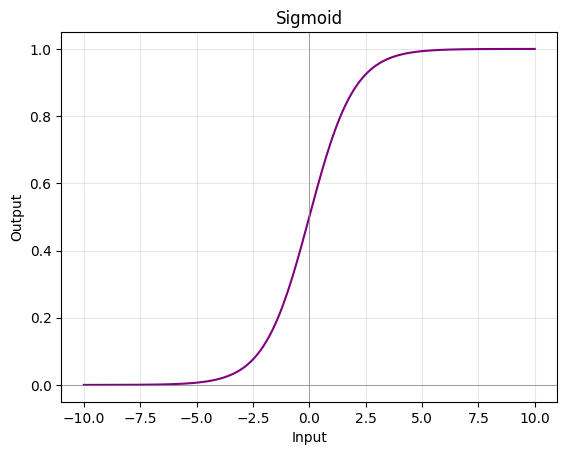

In [3]:
import torch
import matplotlib.pyplot as plt

# Shared input range used for every activation plot below
x = torch.linspace(-10, 10, 200)

def plot_activation(y, title, color):
    """Plot y = f(x) on the shared input range with x/y axes drawn through 0."""
    plt.plot(x.numpy(), y.numpy(), color=color)
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    plt.xlabel('Input'); plt.ylabel('Output')
    plt.title(title); plt.grid(alpha=0.3)
    plt.show()

plot_activation(torch.sigmoid(x), 'Sigmoid', 'purple')

### Why this matters: the vanishing gradient problem

Backpropagation computes gradients by **multiplying** the derivatives along the chain of layers. For sigmoid and tanh:

- The derivative is **largest at $x=0$** — only **0.25** for sigmoid, **1.0** for tanh.
- Once a neuron saturates (curve goes flat), the derivative is essentially **0**.

Stack many such layers and you multiply many small numbers together: the gradient shrinks exponentially with depth and the early layers receive almost no signal. They stop learning. This is the **vanishing gradient problem**, and it is the main reason sigmoid/tanh were replaced by ReLU in deep networks.

The plot below shows the derivatives of sigmoid and tanh — notice how flat they become outside roughly $[-3, 3]$.

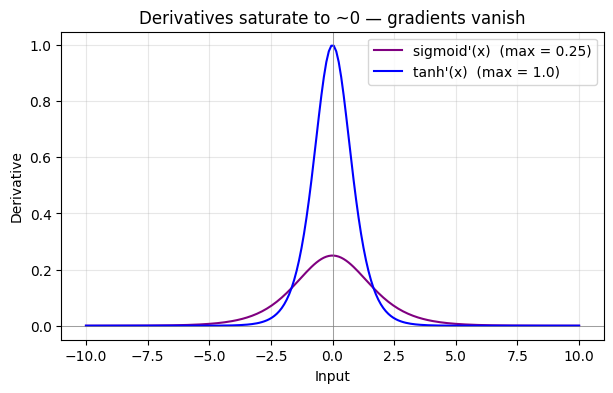

In [8]:
# Closed-form derivatives:  sigmoid'(x) = sigmoid(x) * (1 - sigmoid(x))
#                            tanh'(x)    = 1 - tanh(x)^2
sigmoid_grad = torch.sigmoid(x) * (1 - torch.sigmoid(x))
tanh_grad    = 1 - torch.tanh(x) ** 2

plt.figure(figsize=(7, 4))
plt.plot(x.numpy(), sigmoid_grad.numpy(), color='purple', label="sigmoid'(x)  (max = 0.25)")
plt.plot(x.numpy(), tanh_grad.numpy(),    color='blue',   label="tanh'(x)  (max = 1.0)")
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title('Derivatives saturate to ~0 — gradients vanish')
plt.xlabel('Input'); plt.ylabel('Derivative')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Tanh (Hyperbolic Tangent)

$$\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}$$

- **Range:** $(-1, 1)$ — **zero-centered**, which generally makes optimization easier than sigmoid
- **Used for:** hidden layers in classical neural networks, RNNs
- **Drawback:** still saturates at the extremes (same vanishing-gradient issue as sigmoid)

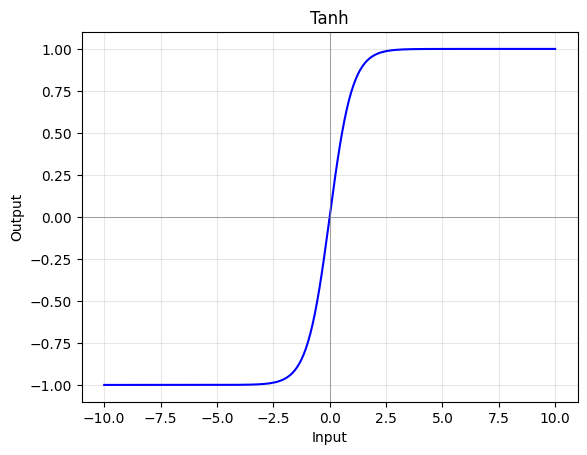

In [4]:
plot_activation(torch.tanh(x), 'Tanh', 'blue')

## ReLU (Rectified Linear Unit)

$$\text{ReLU}(x) = \max(0, x)$$

- **Range:** $[0, \infty)$
- **Why it's the default for hidden layers:** cheap to compute, doesn't saturate for $x > 0$, and produces sparse activations that speed up training
- **Drawback:** **dying ReLU** — neurons stuck on the $x \le 0$ side have zero gradient and stop learning

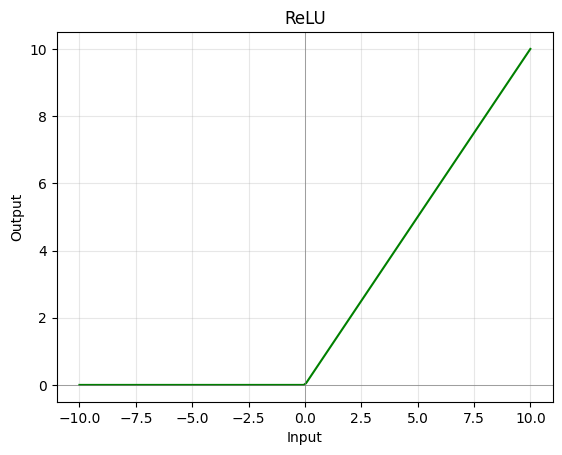

In [5]:
plot_activation(torch.relu(x), 'ReLU', 'green')

### Why this matters: the dying ReLU problem

ReLU's derivative is dead simple — and that's also its weakness:

$$
\frac{d}{dx}\text{ReLU}(x) = \begin{cases} 1 & x > 0 \\ 0 & x \le 0 \end{cases}
$$

If a large gradient update pushes a neuron's weights so that its input is **negative for every training example**, the derivative there is exactly $0$. No gradient flows back through it, so its weights never update again — the neuron is **dead**, permanently outputting 0 for the rest of training.

**Leaky ReLU** fixes this by keeping a small slope $\alpha$ on the negative side, so the derivative is $\alpha$ instead of $0$. There is always *some* gradient available to revive the neuron.

## Leaky ReLU

$$
\text{LeakyReLU}(x) = \begin{cases} x & x \ge 0 \\ \alpha\, x & x < 0 \end{cases}
$$

A small negative slope $\alpha$ (commonly $0.01$ or $0.1$) keeps a non-zero gradient for negative inputs, fixing the **dying ReLU** problem while keeping ReLU's efficiency.

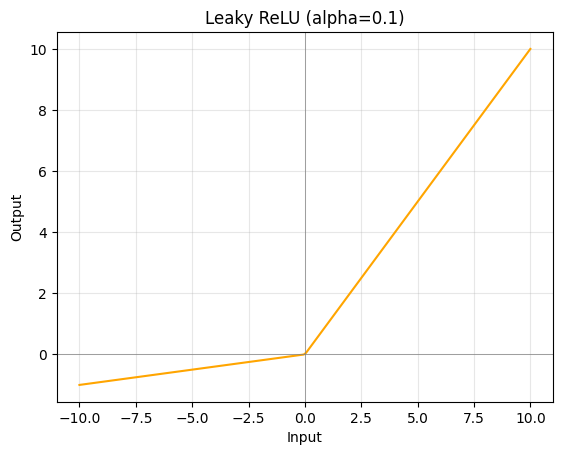

In [6]:
# negative_slope is alpha; 0.1 is exaggerated for visibility (0.01 is more common in practice)
y = torch.nn.functional.leaky_relu(x, negative_slope=0.1)
plot_activation(y, 'Leaky ReLU (alpha=0.1)', 'orange')